## Cell 0 — Mount Drive & Cài thư viện

In [1]:
!pip install numpy==1.26.4 scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 12.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 106.1 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554970 sha256=97d075cbf3148ecc1e4ba5b30355cccf618e71fab8cfc3a336e9132b74fcde37
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following

In [1]:
!pip install implicit torch pyarrow -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [8]:
!pip install torch


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
print(f'   GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU"}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

   GPU: Tesla T4


In [3]:
import numpy as np
import pandas as pd
import pickle, json, time, gc
from pathlib import Path
from scipy import sparse
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from tqdm.auto import tqdm

from surprise import SVD, SVDpp, Dataset, Reader
from surprise import accuracy as surprise_accuracy

import implicit

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset as TorchDataset, DataLoader

DRIVE_ROOT  = Path('/content/drive/MyDrive/amazon_clothing')
MODELS_DIR  = DRIVE_ROOT / 'outputs' / 'models'
FIGURES_DIR = DRIVE_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

all_rec_results = {}

In [4]:
print('load dữ liệu...')

df_train     = pd.read_parquet(MODELS_DIR / 'rec_train.parquet')
df_test      = pd.read_parquet(MODELS_DIR / 'rec_test.parquet')
train_matrix = sparse.load_npz(str(MODELS_DIR / 'train_matrix.npz'))
test_matrix  = sparse.load_npz(str(MODELS_DIR / 'test_matrix.npz'))

with open(MODELS_DIR / 'user_encoder.pkl', 'rb') as f:
    user_encoder = pickle.load(f)
with open(MODELS_DIR / 'item_encoder.pkl', 'rb') as f:
    item_encoder = pickle.load(f)
with open(MODELS_DIR / 'rec_metadata.json', 'r') as f:
    metadata = json.load(f)

N_USERS = metadata['n_users']
N_ITEMS = metadata['n_items']

print(f'   Train  : {len(df_train):,} ratings')
print(f'   Test   : {len(df_test):,} ratings')
print(f'   Users  : {N_USERS:,}')
print(f'   Items  : {N_ITEMS:,}')
print(f'   Matrix : {train_matrix.shape} | density={metadata["sparsity"]:.6%}')

load dữ liệu...
   Train  : 20,551,232 ratings
   Test   : 5,599,171 ratings
   Users  : 3,195,711
   Items  : 1,260,717
   Matrix : (3195711, 1260717) | density=99.999490%


TOP_CANDIDATES_V2 & Hàm Evaluate chung

In [5]:
print('Xây dựng TOP_CANDIDATES_V2...')

train_items   = set(df_train['item_idx'].unique())
test_items    = set(df_test['item_idx'].unique())
overlap_items = train_items & test_items

item_pop = (
    df_train[df_train['item_idx'].isin(overlap_items)]
    .groupby('item_idx').size()
    .sort_values(ascending=False)
)
TOP_CANDIDATES_V2 = item_pop.head(5000).index.tolist()

# Verify overlap với relevant test items
all_relevant = set()
for s in df_test[df_test['rating'] >= 4].groupby('user_idx')['item_idx'].apply(set).values:
    all_relevant.update(s)
overlap_check = len(set(TOP_CANDIDATES_V2) & all_relevant)

print(f'   Train items        : {len(train_items):,}')
print(f'   Test items         : {len(test_items):,}')
print(f'   Overlap train∩test : {len(overlap_items):,}')
print(f'   TOP_CANDIDATES_V2  : {len(TOP_CANDIDATES_V2):,}')
print(f'   Overlap với relevant test: {overlap_check:,}')

# hàm đánh giá

def compute_rmse_mae(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae

def compute_ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    dcg  = sum(1/np.log2(i+2) for i, item in enumerate(recommended) if item in relevant)
    idcg = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0

def evaluate_topk(model_predict_fn, df_test, K=10, n_sample_users=500):
    relevant_items = (
        df_test[df_test['rating'] >= 4]
        .groupby('user_idx')['item_idx'].apply(set).to_dict()
    )
    valid_users = list(relevant_items.keys())
    if len(valid_users) > n_sample_users:
        np.random.seed(42)
        valid_users = np.random.choice(valid_users, n_sample_users, replace=False)

    precision_list, recall_list, ndcg_list = [], [], []
    for user_idx in tqdm(valid_users, desc=f'Evaluating Top-{K}', leave=False):
        relevant = relevant_items[user_idx]
        try:
            recommended = model_predict_fn(user_idx, K)
        except Exception:
            continue
        if not recommended:
            continue
        hits = len(set(recommended[:K]) & relevant)
        precision_list.append(hits / K)
        recall_list.append(hits / len(relevant) if relevant else 0)
        ndcg_list.append(compute_ndcg_at_k(recommended, relevant, K))

    return {
        f'precision@{K}': round(np.mean(precision_list), 4) if precision_list else 0.0,
        f'recall@{K}'   : round(np.mean(recall_list), 4)    if recall_list    else 0.0,
        f'ndcg@{K}'     : round(np.mean(ndcg_list), 4)      if ndcg_list      else 0.0,
    }

Xây dựng TOP_CANDIDATES_V2...
   Train items        : 1,133,776
   Test items         : 469,221
   Overlap train∩test : 342,280
   TOP_CANDIDATES_V2  : 5,000
   Overlap với relevant test: 4,984


---
# THUẬT TOÁN 1 — SVD


In [6]:
SURPRISE_SAMPLE = 2_000_000
print(f'Chuẩn bị Surprise data ({SURPRISE_SAMPLE:,} samples)...')

df_surprise   = df_train.sample(n=min(SURPRISE_SAMPLE, len(df_train)), random_state=42)\
                         [['user_idx','item_idx','rating']].copy()
reader        = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(df_surprise[['user_idx','item_idx','rating']], reader)
trainset      = surprise_data.build_full_trainset()

df_test_sample = df_test.sample(n=min(100_000, len(df_test)), random_state=42)
testset = [(r['user_idx'], r['item_idx'], r['rating']) for _, r in df_test_sample.iterrows()]

print(f'Trainset: {trainset.n_ratings:,} | Testset: {len(testset):,}')

Chuẩn bị Surprise data (2,000,000 samples)...
Trainset: 2,000,000 | Testset: 100,000


In [7]:
print('train SVD:')
t0 = time.time()
svd_model = SVD(n_factors=150, n_epochs=30, lr_all=0.005, reg_all=0.02,
                biased=True, random_state=42, verbose=True)
svd_model.fit(trainset)
train_time = time.time() - t0

svd_preds = svd_model.test(testset)
svd_rmse  = surprise_accuracy.rmse(svd_preds, verbose=False)
svd_mae   = surprise_accuracy.mae(svd_preds, verbose=False)

def svd_predict_topk(user_idx, k=10):
    rated      = set(df_train[df_train['user_idx'] == user_idx]['item_idx'])
    candidates = [i for i in TOP_CANDIDATES_V2 if i not in rated][:1000]
    if not candidates: return []
    scores = [(i, svd_model.predict(user_idx, i).est) for i in candidates]
    scores.sort(key=lambda x: -x[1])
    return [i for i, _ in scores[:k]]

svd_topk   = evaluate_topk(svd_predict_topk, df_test)
mins, secs = int(train_time//60), int(train_time%60)
print(f'\nResults:')
print(f'   Train time: {mins:02d}:{secs:02d} | RMSE: {svd_rmse:.4f} | MAE: {svd_mae:.4f}')
print(f'   {svd_topk}')

with open(MODELS_DIR / 'svd_model.pkl', 'wb') as f: pickle.dump(svd_model, f)
all_rec_results['SVD'] = {
    'model': 'SVD', 'train_time': f'{mins:02d}:{secs:02d}',
    'rmse': round(svd_rmse, 4), 'mae': round(svd_mae, 4), **svd_topk
}

train SVD:
Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
Processing epoch 10
Processing epoch 11
Processing epoch 12
Processing epoch 13
Processing epoch 14
Processing epoch 15
Processing epoch 16
Processing epoch 17
Processing epoch 18
Processing epoch 19
Processing epoch 20
Processing epoch 21
Processing epoch 22
Processing epoch 23
Processing epoch 24
Processing epoch 25
Processing epoch 26
Processing epoch 27
Processing epoch 28
Processing epoch 29


Evaluating Top-10:   0%|          | 0/500 [00:00<?, ?it/s]


Results:
   Train time: 01:37 | RMSE: 1.2258 | MAE: 0.9479
   {'precision@10': 0.0002, 'recall@10': 0.002, 'ndcg@10': 0.002}


---
# THUẬT TOÁN 2 — SVD++


In [9]:

df_surprise_pp   = df_train.sample(n=min(500_000, len(df_train)), random_state=42)\
                            [['user_idx','item_idx','rating']].copy()
surprise_data_pp = Dataset.load_from_df(df_surprise_pp[['user_idx','item_idx','rating']], reader)
trainset_pp      = surprise_data_pp.build_full_trainset()

print('train SVD++')
t0 = time.time()
svdpp_model = SVDpp(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02,
                    random_state=42, verbose=True)
svdpp_model.fit(trainset_pp)
train_time = time.time() - t0

svdpp_preds = svdpp_model.test(testset)
svdpp_rmse  = surprise_accuracy.rmse(svdpp_preds, verbose=False)
svdpp_mae   = surprise_accuracy.mae(svdpp_preds, verbose=False)

def svdpp_predict_topk(user_idx, k=10):
    rated      = set(df_train[df_train['user_idx'] == user_idx]['item_idx'])
    candidates = [i for i in TOP_CANDIDATES_V2 if i not in rated][:1000]
    if not candidates: return []
    scores = [(i, svdpp_model.predict(user_idx, i).est) for i in candidates]
    scores.sort(key=lambda x: -x[1])
    return [i for i, _ in scores[:k]]

svdpp_topk = evaluate_topk(svdpp_predict_topk, df_test)
mins, secs = int(train_time//60), int(train_time%60)
print(f'\nSVD++ Results:')
print(f'   Train time: {mins:02d}:{secs:02d} | RMSE: {svdpp_rmse:.4f} | MAE: {svdpp_mae:.4f}')
print(f'   {svdpp_topk}')

with open(MODELS_DIR / 'svdpp_model.pkl', 'wb') as f: pickle.dump(svdpp_model, f)
all_rec_results['SVD++'] = {
    'model': 'SVD++', 'train_time': f'{mins:02d}:{secs:02d}',
    'rmse': round(svdpp_rmse, 4), 'mae': round(svdpp_mae, 4), **svdpp_topk
}

train SVD++
 processing epoch 0
 processing epoch 1
 processing epoch 2
 processing epoch 3
 processing epoch 4
 processing epoch 5
 processing epoch 6
 processing epoch 7
 processing epoch 8
 processing epoch 9
 processing epoch 10
 processing epoch 11
 processing epoch 12
 processing epoch 13
 processing epoch 14
 processing epoch 15
 processing epoch 16
 processing epoch 17
 processing epoch 18
 processing epoch 19


Evaluating Top-10:   0%|          | 0/500 [00:00<?, ?it/s]


SVD++ Results:
   Train time: 00:24 | RMSE: 1.2330 | MAE: 0.9649
   {'precision@10': 0.0, 'recall@10': 0.0, 'ndcg@10': 0.0}


---
# THUẬT TOÁN 3- Content-Based Filtering


In [10]:
print('load item TF-IDF matrix...')
item_tfidf = sparse.load_npz(str(MODELS_DIR / 'item_tfidf_matrix.npz'))
print(f'   Shape: {item_tfidf.shape}')

with open(MODELS_DIR / 'item_id_to_idx.pkl', 'rb') as f:
    item_id_to_idx = pickle.load(f)

MAX_TFIDF_IDX = item_tfidf.shape[0]
CB_CANDIDATES = [i for i in TOP_CANDIDATES_V2 if i < MAX_TFIDF_IDX]
print(f'   CB candidates: {len(CB_CANDIDATES):,}')

def cb_predict_topk(user_idx, k=10):
    liked = df_train[
        (df_train['user_idx'] == user_idx) & (df_train['rating'] >= 4)
    ]['item_idx'].tolist()
    liked_valid = [i for i in liked if i < MAX_TFIDF_IDX]
    if not liked_valid: return []

    user_vector      = item_tfidf[liked_valid].mean(axis=0)
    candidate_matrix = item_tfidf[CB_CANDIDATES]
    sims             = cosine_similarity(user_vector, candidate_matrix)[0]

    rated = set(df_train[df_train['user_idx'] == user_idx]['item_idx'])
    for j, i in enumerate(CB_CANDIDATES):
        if i in rated: sims[j] = -1

    top_k_idx = np.argsort(sims)[::-1][:k]
    return [CB_CANDIDATES[j] for j in top_k_idx]

print('\nEvaluating Content-Based')
t0        = time.time()
cb_topk   = evaluate_topk(cb_predict_topk, df_test, n_sample_users=200)
eval_time = time.time() - t0
print(f'\nContent-Based Results:')
print(f'   Eval time: {eval_time:.1f}s | RMSE/MAE: N/A')
print(f'   {cb_topk}')

all_rec_results['Content-Based'] = {
    'model': 'Content-Based', 'train_time': 'N/A',
    'rmse': None, 'mae': None, **cb_topk
}

load item TF-IDF matrix...
   Shape: (7218109, 5000)
   CB candidates: 5,000

Evaluating Content-Based


Evaluating Top-10:   0%|          | 0/200 [00:00<?, ?it/s]


Content-Based Results:
   Eval time: 45.4s | RMSE/MAE: N/A
   {'precision@10': 0.0, 'recall@10': 0.0, 'ndcg@10': 0.0}


---
# THUẬT TOÁN 5 — NCF (Neural Collaborative Filtering)


In [11]:

class NCF(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=64):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embed_dim)
        self.item_embedding = nn.Embedding(n_items, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim*2, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),          nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),           nn.ReLU(),
            nn.Linear(32, 1),            nn.Sigmoid()
        )
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)

    def forward(self, user_ids, item_ids):
        x = torch.cat([self.user_embedding(user_ids), self.item_embedding(item_ids)], dim=1)
        return self.mlp(x).squeeze(1)


class RatingDataset(TorchDataset):
    def __init__(self, df):
        self.users   = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.items   = torch.tensor(df['item_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor((df['rating'].values - 1) / 4, dtype=torch.float)
    def __len__(self): return len(self.ratings)
    def __getitem__(self, idx): return self.users[idx], self.items[idx], self.ratings[idx]


NCF_SAMPLE       = 1_000_000
df_ncf_train     = df_train.sample(n=min(NCF_SAMPLE, len(df_train)), random_state=42)
df_ncf_test      = df_test.sample(n=min(200_000, len(df_test)), random_state=42)
ncf_train_loader = DataLoader(RatingDataset(df_ncf_train),
                               batch_size=4096, shuffle=True, num_workers=2, pin_memory=True)
ncf_test_loader  = DataLoader(RatingDataset(df_ncf_test),
                               batch_size=4096, shuffle=False, num_workers=2, pin_memory=True)

ncf_model = NCF(N_USERS, N_ITEMS, embed_dim=64).to(DEVICE)
print(f' Parameters: {sum(p.numel() for p in ncf_model.parameters()):,}')
print(f'   Train: {len(df_ncf_train):,} | Test: {len(df_ncf_test):,}')

 Parameters: 285,238,273
   Train: 1,000,000 | Test: 200,000


In [12]:
N_EPOCHS_NCF  = 5
NCF_SAVE_PATH = MODELS_DIR / 'ncf_model_best.pt'
optimizer_ncf = optim.Adam(ncf_model.parameters(), lr=1e-3)
scheduler_ncf = optim.lr_scheduler.StepLR(optimizer_ncf, step_size=2, gamma=0.7)  # FIX 3
criterion_ncf = nn.MSELoss()
best_rmse_ncf = float('inf')
t_total       = time.time()

print(f'training NCF ({N_EPOCHS_NCF} epochs × {len(df_ncf_train):,} samples)...')

for epoch in range(N_EPOCHS_NCF):
    t0 = time.time()
    ncf_model.train()
    total_loss = 0
    pbar = tqdm(ncf_train_loader, desc=f'  Epoch {epoch+1}/{N_EPOCHS_NCF}', leave=False)
    for users, items, ratings in pbar:
        users, items, ratings = users.to(DEVICE), items.to(DEVICE), ratings.to(DEVICE)
        optimizer_ncf.zero_grad()
        loss = criterion_ncf(ncf_model(users, items), ratings)
        loss.backward(); optimizer_ncf.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Evaluate epoch
    ncf_model.eval()
    preds_ep, trues_ep = [], []
    with torch.no_grad():
        for users, items, ratings in ncf_test_loader:
            preds = np.clip(ncf_model(users.to(DEVICE), items.to(DEVICE)).cpu().numpy() * 4 + 1, 1, 5)
            preds_ep.extend(preds); trues_ep.extend(ratings.numpy() * 4 + 1)

    rmse_ep, mae_ep = compute_rmse_mae(trues_ep, preds_ep)
    print(f'  Epoch {epoch+1}: Loss={total_loss/len(ncf_train_loader):.4f} | '
          f'RMSE={rmse_ep:.4f} | MAE={mae_ep:.4f} | {time.time()-t0:.0f}s')

    if rmse_ep < best_rmse_ncf:
        best_rmse_ncf = rmse_ep
        torch.save(ncf_model.state_dict(), NCF_SAVE_PATH)
        print(f'  💾 Saved best (RMSE={best_rmse_ncf:.4f})')
    scheduler_ncf.step()

train_time = time.time() - t_total

# FIX 1: Load best model → RE-EVALUATE (không dùng preds_ep epoch cuối)
print('\nRe-evaluating best model...')
ncf_model.load_state_dict(torch.load(NCF_SAVE_PATH))
ncf_model.eval()
preds_best, trues_best = [], []
with torch.no_grad():
    for users, items, ratings in tqdm(ncf_test_loader, desc='Final eval', leave=False):
        preds = np.clip(ncf_model(users.to(DEVICE), items.to(DEVICE)).cpu().numpy() * 4 + 1, 1, 5)
        preds_best.extend(preds); trues_best.extend(ratings.numpy() * 4 + 1)
ncf_rmse, ncf_mae = compute_rmse_mae(trues_best, preds_best)

# FIX 2: Top-K dùng TOP_CANDIDATES_V2
def ncf_predict_topk(user_idx, k=10):
    rated      = set(df_train[df_train['user_idx'] == user_idx]['item_idx'])
    candidates = [i for i in TOP_CANDIDATES_V2 if i not in rated][:1000]
    if not candidates: return []
    ncf_model.eval()
    with torch.no_grad():
        scores = ncf_model(
            torch.tensor([user_idx]*len(candidates), dtype=torch.long).to(DEVICE),
            torch.tensor(candidates, dtype=torch.long).to(DEVICE)
        ).cpu().numpy()
    return list(np.array(candidates)[np.argsort(scores)[::-1][:k]])

ncf_topk   = evaluate_topk(ncf_predict_topk, df_test)
mins, secs = int(train_time//60), int(train_time%60)
print(f'\nNCF Final Results:')
print(f'   Train time: {mins:02d}:{secs:02d} | RMSE: {ncf_rmse:.4f} | MAE: {ncf_mae:.4f}')
print(f'   {ncf_topk}')

all_rec_results['NCF'] = {
    'model': 'NCF', 'train_time': f'{mins:02d}:{secs:02d}',
    'rmse': round(ncf_rmse, 4), 'mae': round(ncf_mae, 4), **ncf_topk
}

training NCF (5 epochs × 1,000,000 samples)...


  Epoch 1/5:   0%|          | 0/245 [00:00<?, ?it/s]

  Epoch 1: Loss=0.0993 | RMSE=1.2372 | MAE=0.9748 | 43s
  💾 Saved best (RMSE=1.2372)


  Epoch 2/5:   0%|          | 0/245 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c737543ba60><function _MultiProcessingDataLoaderIter.__del__ at 0x7c737543ba60>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       if w.is_alive():  
   ^ ^ ^^  ^ ^ ^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ 
  File "/usr/lib/pytho

...

  Epoch 5: Loss=0.0096 | RMSE=1.3744 | MAE=1.0890 | 41s

Re-evaluating best model...


Final eval:   0%|          | 0/49 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c737543ba60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^Exception ignored in: ^^^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c737543ba60>
^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    self._shutdown_workers()^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^    if w.is_alive():^
 ^
   File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
       assert self._parent_pid == os.getpid(), 'can only test a child process'
       ^^ ^^ ^ ^ ^ ^ ^^^^^^^^
^  File 

Evaluating Top-10:   0%|          | 0/500 [00:00<?, ?it/s]


NCF Final Results:
   Train time: 06:06 | RMSE: 1.2372 | MAE: 0.9748
   {'precision@10': 0.0002, 'recall@10': 0.002, 'ndcg@10': 0.0007}


So sánh tất cả 5 thuật toán

Saved: rec_all_results.json
SO SÁNH 5 THUẬT TOÁN RECOMMENDATION
        model train_time   rmse    mae  precision@10  recall@10  ndcg@10
          SVD      01:37 1.2258 0.9479        0.0002      0.002   0.0020
        SVD++      00:24 1.2330 0.9649        0.0000      0.000   0.0000
Content-Based        N/A    NaN    NaN        0.0000      0.000   0.0000
          NCF      06:06 1.2372 0.9748        0.0002      0.002   0.0007


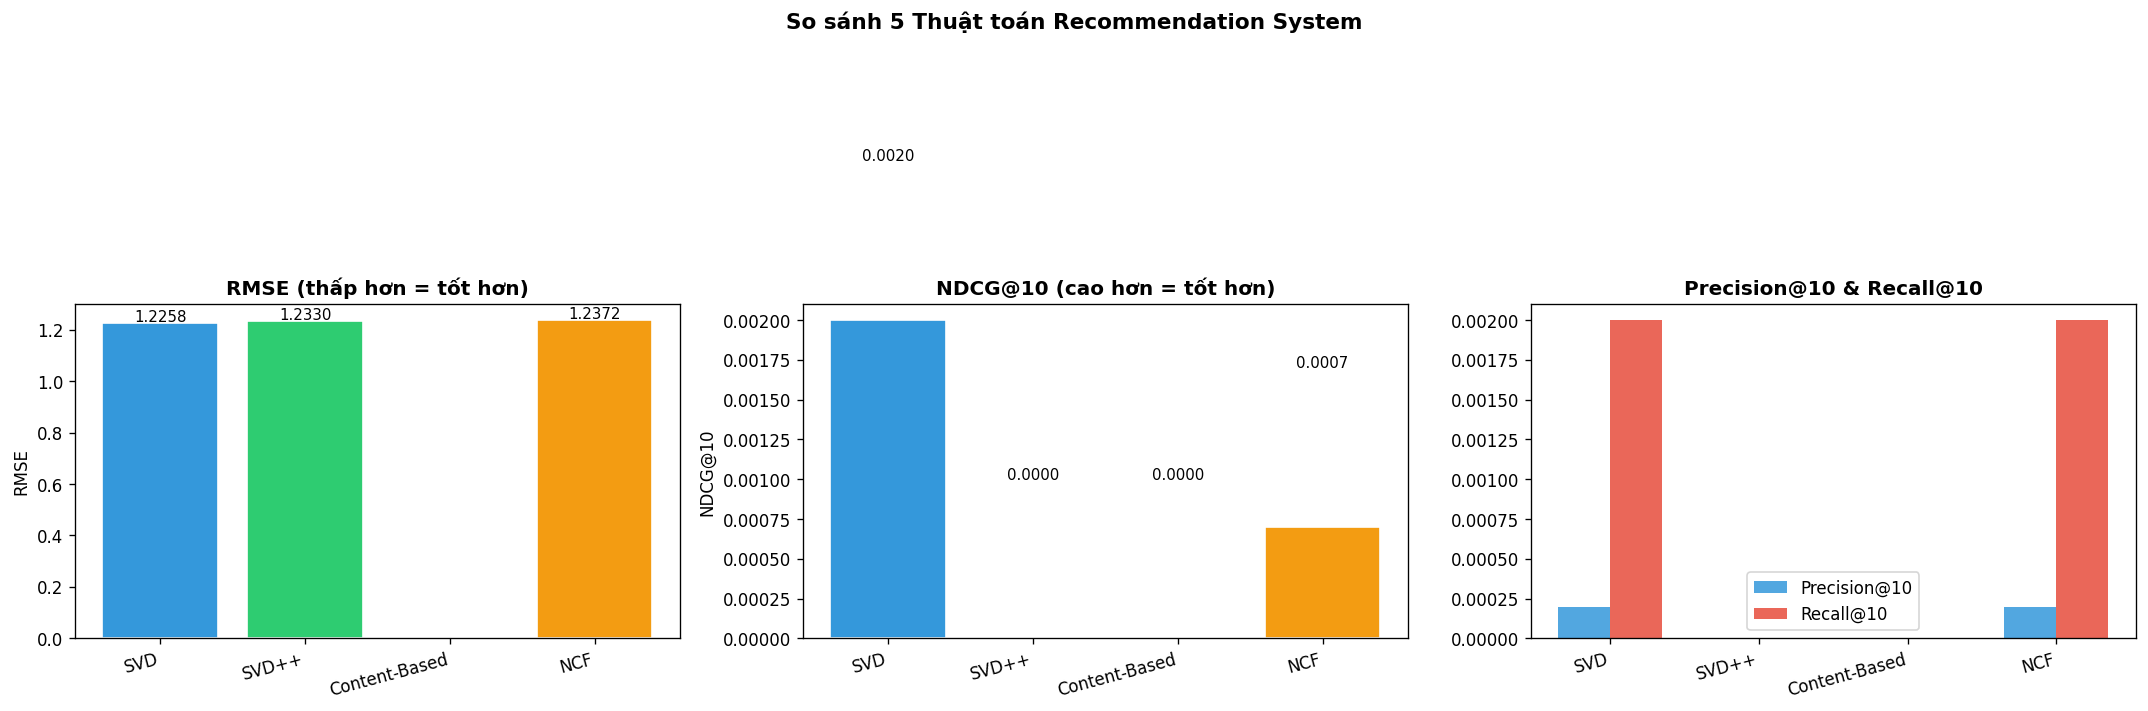


Best model (NDCG@10): SVD
   RMSE    : 1.2258
   NDCG@10 : 0.002


In [16]:
with open(MODELS_DIR / 'rec_all_results.json', 'w') as f:
    json.dump(all_rec_results, f, indent=2, default=str)
print('Saved: rec_all_results.json')

df_rec_results = pd.DataFrame(list(all_rec_results.values()))

print('SO SÁNH 5 THUẬT TOÁN RECOMMENDATION')
print(df_rec_results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('So sánh 5 Thuật toán Recommendation System', fontsize=13, fontweight='bold')
models = df_rec_results['model'].tolist()
x      = range(len(models))
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

rmse_vals = [r if r is not None else 0 for r in df_rec_results['rmse'].tolist()]
bars = axes[0].bar(x, rmse_vals, color=colors, edgecolor='white')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_title('RMSE (thấp hơn = tốt hơn)', fontweight='bold'); axes[0].set_ylabel('RMSE')
for bar, val in zip(bars, rmse_vals):
    if val > 0: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                              f'{val:.4f}', ha='center', fontsize=9)

ndcg_col  = [c for c in df_rec_results.columns if 'ndcg' in c][0]
ndcg_vals = df_rec_results[ndcg_col].tolist()
bars = axes[1].bar(x, ndcg_vals, color=colors, edgecolor='white')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_title(f'{ndcg_col.upper()} (cao hơn = tốt hơn)', fontweight='bold')
axes[1].set_ylabel('NDCG@10')
for bar, val in zip(bars, ndcg_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                  f'{val:.4f}', ha='center', fontsize=9)

prec_col   = [c for c in df_rec_results.columns if 'precision' in c][0]
recall_col = [c for c in df_rec_results.columns if 'recall' in c][0]
w = 0.35
axes[2].bar([i-w/2 for i in x], df_rec_results[prec_col], width=w,
             label='Precision@10', color='#3498db', alpha=0.85)
axes[2].bar([i+w/2 for i in x], df_rec_results[recall_col], width=w,
             label='Recall@10', color='#e74c3c', alpha=0.85)
axes[2].set_xticks(list(x)); axes[2].set_xticklabels(models, rotation=15, ha='right')
axes[2].set_title('Precision@10 & Recall@10', fontweight='bold'); axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step6_recommendation_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

best_model = df_rec_results.iloc[df_rec_results[ndcg_col].idxmax()]
print(f'\nBest model (NDCG@10): {best_model["model"]}')
print(f'   RMSE    : {best_model["rmse"]}')
print(f'   NDCG@10 : {best_model[ndcg_col]}')